In [4]:
## setup
from pathlib import Path
import sys
ROOT_PATH = (Path.cwd().parents[1]).as_posix()

if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)
import numpy as np
from src.model.flow_matching_model import GaussianPriorFlowMatching
from src.config import Config
import yaml
from pathlib import Path
import src.dataset as datasets
import torch
import matplotlib.pyplot as plt
from src.model.flow_matching_model.samples import Samples

WRAPPER_MAP = {
    "GaussianPriorFlowMatching": GaussianPriorFlowMatching,
}

def load_config(path):
    with open(path, "r") as f:
        yaml_dict = yaml.safe_load(f)
    return Config(**yaml_dict)

def load_experiment(folder_path, checkpoint_name):
    config_path = Path(ROOT_PATH)/ Path(folder_path) / Path("config.yaml")
    checkpoint_path = Path(ROOT_PATH)/ Path(folder_path) / Path(checkpoint_name)
    config = load_config(config_path)
    config.data.dataset_folder = str(Path(ROOT_PATH) / Path(config.data.dataset_folder))
    data_module = getattr(datasets, config.data.data_class)(config.data)
    wrapper = WRAPPER_MAP[config.lightning_wrapper](config)
    checkpoint = torch.load(checkpoint_path,map_location="cpu", weights_only="False")
    wrapper.load_state_dict(checkpoint["state_dict"], strict=True)
    return wrapper, data_module


In [5]:
## AR1
def estimate_ar1_coeffs_from_cov(curves):
    """
    curves: ndarray [B, N]
    returns: ndarray [B, 1] with estimated AR(1) coefficient phi
    """

    # remove burn-in
    x = curves[:]          # [B, N']
    B, N = x.shape

    # center each curve
    x = x - x.mean(axis=1, keepdims=True)

    # autocovariances γ(0) and γ(1)
    g0 = np.sum(x * x, axis=1) / N
    g1 = np.sum(x[:, 1:] * x[:, :-1], axis=1) / (N - 1)

    # AR(1) Yule–Walker
    phi = (g1 / g0)[:, None]         # [B, 1]

    return phi

def ar1_log_likelihood(curves, phi):
    """
    Compute AR(1) Gaussian log-likelihood for a batch of curves.

    curves: ndarray [B, N]
    phi:    ndarray [B, 1] or [B] or scalar

    returns: ndarray [B] log-likelihood per curve
    """

    x = curves
    B, N = x.shape

    # center each curve (same as your estimator)
    x = x - x.mean(axis=1, keepdims=True)

    # ensure phi shape is [B, 1]
    phi = np.asarray(phi)
    if phi.ndim == 0:
        phi = np.full((B, 1), phi)
    elif phi.ndim == 1:
        phi = phi[:, None]

    # AR(1) residuals: e_t = x_t - phi * x_{t-1}
    resid = x[:, 1:] - phi * x[:, :-1]   # [B, N-1]

    # MLE estimate of sigma^2 per curve
    sigma2 = np.mean(resid**2, axis=1)   # [B]

    # log-likelihood per curve
    ll = (
        -0.5 * (N - 1) * np.log(2 * np.pi * sigma2)
        -0.5 * np.sum(resid**2, axis=1) / sigma2
    )

    return ll

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
ROOT_PATH = Path.cwd().parent.parent

import numpy as np 
import torch
import matplotlib.pyplot as plt 
from src.utils.drw import DRWManager


NUM_TOTAL_SAMPLES = 512
CONDITION_SLICE = slice(256, 512)


def sample_drw_curves(num_curves, coeff, sigma=0.1):
    manager = DRWManager(sigma=sigma, observation_noise=0.0)
    parameters = torch.full((num_curves, 1), float(coeff), dtype=torch.float32)
    curves = manager.simulate_from_params(parameters, num_samples=NUM_TOTAL_SAMPLES, burn_in=256)
    return curves[:, CONDITION_SLICE]


In [ ]:
## load model
folder_path = "outputs/gaussian prior - conditional generation"
checkpoint_name = "step=step=023500.ckpt"
model_wrapper, data_module = load_experiment(folder_path, checkpoint_name)
model_wrapper.to("cuda")

sigma_drw = 0.1
target_coeffs = np.linspace(0.2,0.9,9) 

num_curves = 500
data_curves_dict = {
    coeff: model_wrapper.to_domain(Samples(sample_drw_curves(num_curves, coeff, sigma_drw), "time", t=1)).curves
    for coeff in target_coeffs
}

coeff_curve_model_map = {}
for coeff, curves in data_curves_dict.items():
    condition = model_wrapper.encode(torch.tensor(curves, dtype=torch.float32, device="cuda"))
    resampled_curves = model_wrapper.to_domain(model_wrapper.domain_sample(condition.shape[0], condition=condition, num_steps=30), "time").curves
    coeff_curve_model_map[coeff] = resampled_curves.cpu().numpy()

coeff_distribtions = {}
for coeff, curves in coeff_curve_model_map.items():
    estiamted_coeffs = estimate_ar1_coeffs_from_cov(curves)

    coeff_distribtions[coeff] = estiamted_coeffs

for coeff in coeff_distribtions.keys():
    x = np.zeros_like(coeff_distribtions[coeff]) + coeff
    plt.scatter(x, coeff_distribtions[coeff], alpha=0.005)
    plt.scatter([x[0]], [coeff_distribtions[coeff].mean()], alpha=1)
    # plt.scatter([coeff], [coeff_distribtions[coeff].mean()])
x = list(coeff_distribtions.keys())
plt.plot(x, x, c="red", alpha=0.1)
plt.show()

/tmp/ipykernel_1901070/2444410235.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  condition = model_wrapper.encode(torch.tensor(curves, dtype=torch.float32, device="cuda"))


ValueError: too many values to unpack (expected 2)

In [4]:
num_curves = 3000
model_curves = model_wrapper.to_domain(model_wrapper.domain_sample(num_curves, num_steps=50))
model_curves_domain = model_curves.curves[:]
model_curves_time = model_wrapper.to_domain(model_curves, "time").curves
condition = model_wrapper.encode(model_curves_domain)
resampled_curves = model_wrapper.domain_sample(num_curves, condition=condition, num_steps=50)
resampled_curves_time = model_wrapper.to_domain(resampled_curves, "time").curves

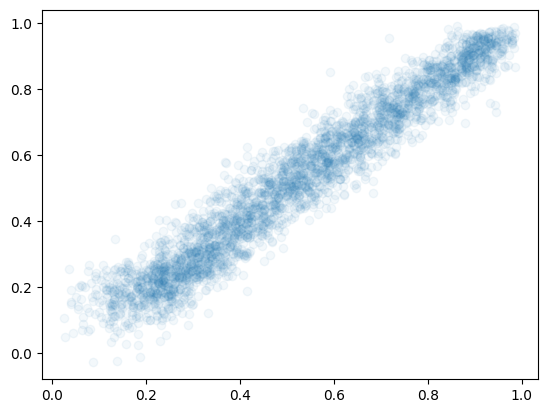

In [5]:
original_curve_coeff = estimate_ar1_coeffs_from_cov(model_curves_time.cpu().numpy())
conditioned_curve_coeff = estimate_ar1_coeffs_from_cov(resampled_curves_time.cpu().numpy())
plt.scatter(original_curve_coeff, conditioned_curve_coeff, alpha=0.05)
plt.show()

### regular coeff estimation

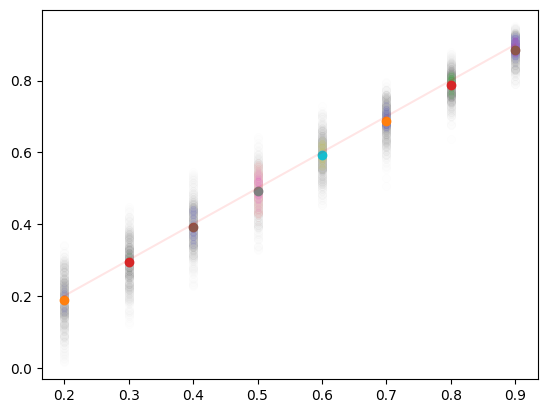

In [7]:
sigma_drw = 0.1
target_coeffs = np.linspace(0.2, 0.9, 8) 

num_curves = 500
data_curves_dict = {
    coeff: sample_drw_curves(num_curves, coeff, sigma_drw)
    for coeff in target_coeffs
}
coeff_distribution = {
    coeff: estimate_ar1_coeffs_from_cov(curves.cpu().numpy())
    for coeff, curves in data_curves_dict.items()
}
for coeff, coeffs in coeff_distribution.items():
    x = np.zeros_like(coeffs) + coeff
    plt.scatter(x, coeffs, alpha=0.005)
    plt.scatter([coeff], [coeffs.mean()])
x = list(coeff_distribution.keys())
plt.plot(x, x, c="red", alpha=0.1)
plt.show()

### plots for paper

/tmp/ipykernel_1901070/558725828.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(curves, dtype=torch.float32, device="cuda")


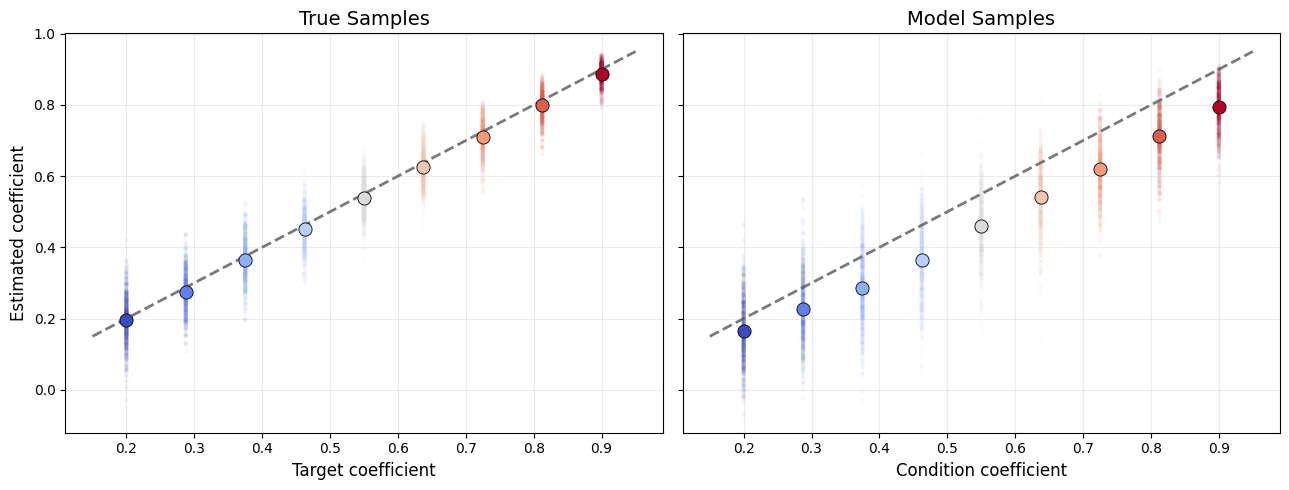

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# =========================
# Figure + axes
# =========================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sigma_drw = 0.1
target_coeffs = np.linspace(0.2, 0.9, 9)

num_curves = 500

# =========================
# Colormap setup
# =========================
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=target_coeffs.min(), vmax=target_coeffs.max())

# =========================
# Panel 1: Ground truth
# =========================
ax = axes[0]

data_curves_dict = {
    coeff: sample_drw_curves(num_curves, coeff, sigma_drw)
    for coeff in target_coeffs
}

coeff_distribution = {
    coeff: estimate_ar1_coeffs_from_cov(curves.cpu().numpy())
    for coeff, curves in data_curves_dict.items()
}

for coeff, coeffs in coeff_distribution.items():
    col = cmap(norm(coeff))
    x = np.full_like(coeffs, coeff)

    ax.scatter(x, coeffs, alpha=0.06, s=10, color=col, edgecolors="none")
    ax.scatter(
        [coeff], [coeffs.mean()],
        s=90,
        color=col,
        edgecolor="black",
        linewidth=0.6,
        zorder=5
    )

xline = np.linspace(0.15, 0.95, 200)
ax.plot(xline, xline, color="0.35", linestyle="--", linewidth=2, alpha=0.8)

ax.set_title("True Samples", fontsize=14)
ax.set_xlabel("Target coefficient", fontsize=12)
ax.set_ylabel("Estimated coefficient", fontsize=12)
ax.grid(alpha=0.25)

# =========================
# Panel 2: Model output
# =========================
ax = axes[1]

folder_path = "outputs/gaussian prior - conditional generation"
# folder_path = "outputs/gaussian prior - conditional generation - no contrastive"
checkpoint_name = "step=step=023500.ckpt"

model_wrapper, data_module = load_experiment(folder_path, checkpoint_name)
model_wrapper.to("cuda")

data_curves_dict = {
    coeff: model_wrapper.to_domain(
        Samples(
            sample_drw_curves(num_curves, coeff, sigma_drw),
            "time",
            t=1
        )
    ).curves
    for coeff in target_coeffs
}

coeff_curve_model_map = {}

for coeff, curves in data_curves_dict.items():
    condition = model_wrapper.encode(
        torch.tensor(curves, dtype=torch.float32, device="cuda")
    )

    resampled_curves = model_wrapper.to_domain(
        model_wrapper.domain_sample(
            condition.shape[0],
            condition=condition,
            num_steps=30
        ),
        "time"
    ).curves

    coeff_curve_model_map[coeff] = resampled_curves.cpu().numpy()

coeff_distributions = {
    coeff: estimate_ar1_coeffs_from_cov(curves.squeeze())
    for coeff, curves in coeff_curve_model_map.items()
}

for coeff, coeffs in coeff_distributions.items():
    col = cmap(norm(coeff))
    x = np.full_like(coeffs, coeff)

    ax.scatter(x, coeffs, alpha=0.06, s=10, color=col, edgecolors="none")
    ax.scatter(
        [coeff], [coeffs.mean()],
        s=90,
        color=col,
        edgecolor="black",
        linewidth=0.6,
        zorder=5
    )

ax.plot(xline, xline, color="0.35", linestyle="--", linewidth=2, alpha=0.8)

ax.set_title("Model Samples", fontsize=14)
ax.set_xlabel("Condition coefficient", fontsize=12)
ax.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("conditional generation.png", dpi=500)


### testing coefficient distribution

In [8]:
coeff = 0.2
num_curves = 5000
condition_curves = sample_drw_curves(1, coeff, sigma_drw).to("cuda")
condition = model_wrapper.encode((model_wrapper.to_domain(Samples(condition_curves, "time", t=1))).curves)
conditional_curves = model_wrapper.to_domain(model_wrapper.domain_sample(num_curves, condition=condition.repeat(num_curves, 1)), "time").curves
coeffs = estimate_ar1_coeffs_from_cov(conditional_curves.cpu().numpy())

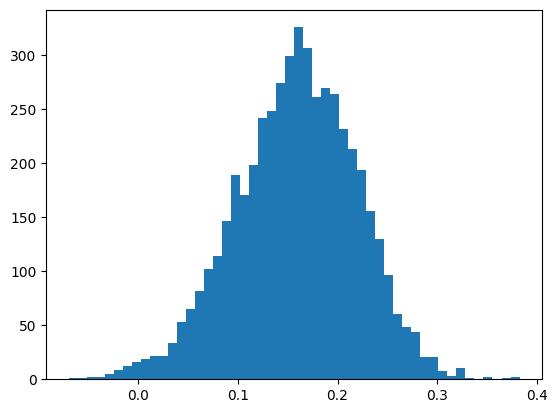

In [9]:
plt.hist(coeffs, bins=50)
plt.show()

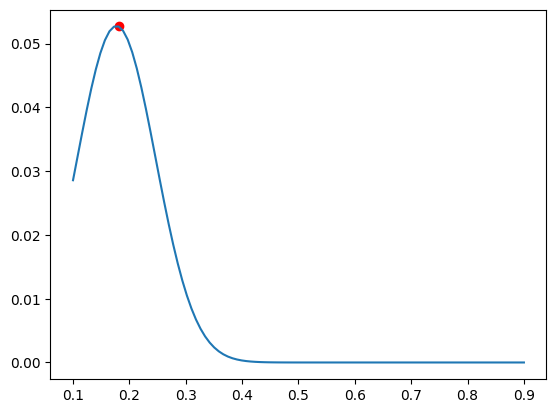

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def ar1_loglik_fixed_sigma_single(x, phi_grid, sigma2):
    """
    x:        [N] numpy
    phi_grid: [K] numpy
    sigma2:   scalar

    returns: [K] log-likelihoods
    """
    x = x - x.mean()
    x0 = x[:-1][None, :]                 # [1, N-1]
    x1 = x[1:][None, :]                  # [1, N-1]
    phi = phi_grid[:, None]              # [K, 1]

    resid = x1 - phi * x0                # [K, N-1]
    N = x.shape[0]

    ll = -0.5 * (N - 1) * np.log(2*np.pi*sigma2) - 0.5 * np.sum(resid**2, axis=1) / sigma2
    return ll

def softmax_np(logits):
    logits = logits - logits.max()
    p = np.exp(logits)
    return p / p.sum()

coeff_true = 0.2
x = sample_drw_curves(1, coeff_true, sigma_drw)[0].cpu().numpy()

phi_grid = np.linspace(0.1, 0.9, 100)

sigma2 = sigma_drw**2   # pick something consistent for your data units
ll = ar1_loglik_fixed_sigma_single(x, phi_grid, sigma2)
post = softmax_np(ll)

argmax = np.argmax(post)
plt.plot(phi_grid, post)
plt.scatter([phi_grid[argmax]], [post[argmax]], c="red")


In [86]:
# =========================
# Block 1: Calculations
# =========================
results = []

for coeff_true in COEFF_TRUES:
    seed_everything(SEED + int(round(coeff_true * 1000)))

    x = sample_drw_curves(1, coeff_true, sigma_drw)[0]
    x_np = x.detach().cpu().numpy()
    sigma2 = float(sigma_drw**2)

    ll = ar1_loglik_fixed_sigma_single(x_np, PHI_GRID, sigma2)
    post = softmax_np(ll)

    post_argmax = int(np.argmax(post))
    post_phi_hat = float(PHI_GRID[post_argmax])

    with torch.no_grad():
        x_cuda = x.to("cuda")[None]
        condition = model_wrapper.encode(
            model_wrapper.to_domain(Samples(x_cuda, "time", t=1)).curves
        )
        conditional_curves = model_wrapper.to_domain(
            model_wrapper.domain_sample(NUM_CURVES, condition=condition.repeat(NUM_CURVES, 1)),
            "time"
        ).curves

    model_coeffs = estimate_ar1_coeffs_from_cov(
        conditional_curves.detach().cpu().numpy()
    ).squeeze()
    model_coeffs = np.asarray(model_coeffs, dtype=np.float64)

    results.append({
        "coeff_true": coeff_true,
        "model_coeffs": model_coeffs,
        "post": post,
        "post_phi_hat": post_phi_hat,
        "post_argmax": post_argmax,
    })


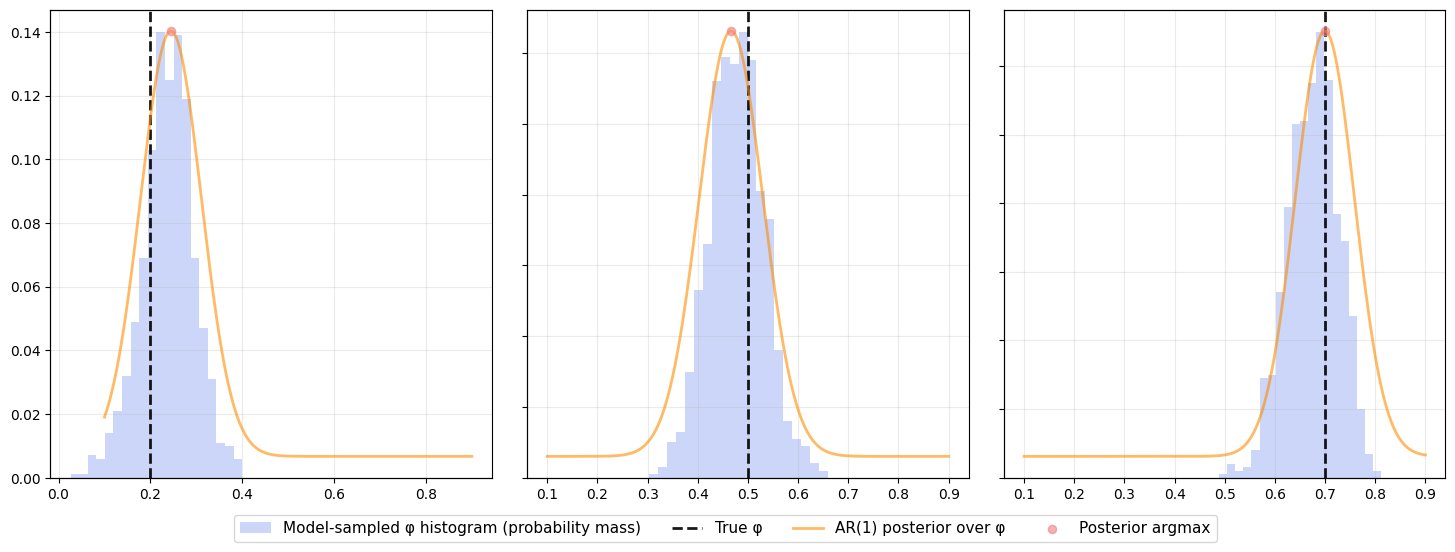

In [103]:
# =========================
# Block 2: Plotting (tight + room for legend)
# =========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6.0),
    constrained_layout=False
)

for i, (ax, res) in enumerate(zip(axes, results)):
    coeff_true = res["coeff_true"]
    model_coeffs = res["model_coeffs"]
    post = res["post"]
    post_phi_hat = res["post_phi_hat"]
    post_argmax = res["post_argmax"]

    weights = np.ones_like(model_coeffs) / model_coeffs.size

    h_hist = ax.hist(
        model_coeffs,
        bins=NUM_BINS,
        weights=weights,
        alpha=0.35,
        edgecolor="none",
        color=plt.cm.coolwarm(0.15),
        label="Model-sampled φ histogram"
    )

    h_true = ax.axvline(
        coeff_true,
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        color="black",
        label="True φ"
    )

    ax.grid(True, axis="both", alpha=0.25)

    if i != 0:
        ax.tick_params(axis="y", labelleft=False)

    ax2 = ax.twinx()

    h_post, = ax2.plot(
        PHI_GRID,
        post,
        linewidth=2,
        alpha=0.6,
        color="darkorange",
        label="AR(1) posterior over φ"
    )

    h_hat = ax2.scatter(
        [post_phi_hat],
        [post[post_argmax]],
        s=35,
        zorder=3,
        color="lightcoral",
        alpha=0.6,
        label="Posterior argmax"
    )

    ax2.tick_params(axis="y", right=False, labelright=False)
    ax2.spines["right"].set_visible(False)

# =========================
# Global legend BELOW plots
# =========================
handles = [h_hist[2][0], h_true, h_post, h_hat]
labels = [
    "Model-sampled φ histogram (probability mass)",
    "True φ",
    "AR(1) posterior over φ",
    "Posterior argmax"
]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)

# =========================
# Tight spacing between subplots + room for legend
# =========================
plt.subplots_adjust(
    wspace=0.08,   # tighter horizontal spacing
    bottom=0.1    # space for legend
)

plt.savefig("model conditional likelihood match.png", dpi=500, bbox_inches="tight")
plt.show()
